# 03 · Misconception chains, pin-configuration ablation

Trains the five misconception chains under a ladder of pin configurations and compares them per family, so that one configuration can be picked as the chain of record for the gate stage.

**The design goals a configuration can implement:**

- Dispositions start low and stay low while only A or N cells are observed.
- A P cell raises the disposition. This holds in every configuration through the emission asymmetry, P is far likelier from the active state, and needs no pin.
- An A cell after a P drops the disposition sharply.
- An N cell after a P gives a small decline that compounds over consecutive Ns, and the disposition can never converge upward under silence, which the onset pin guarantees structurally, the stationary point of an unevidenced chain is zero.

**Selection criterion, pre-registered.** Primary is AUC per family, threshold-free and what the gate consumes. Ties break on the TPR and TNR balance.

**Metrics**, computed per family on held-out informative test cells with P the positive class:

- `accuracy`, all informative cells at threshold 0.5.
- `tpr`, recall on P cells.
- `tnr`, recall on A cells.
- `auc`, threshold-free ranking of P cells above A cells.
- `f1`, harmonic mean of precision and recall on P.
- `informative_cells`, the number of scored cells, the denominator that says whether the row means anything.

## 1. Setup

In [1]:
import pandas as pd
from scripts.load_data import load_paper_filtered_data
from scripts.chain import Chain, TriggerChain
from scripts.misconception_chains import MisconceptionChains, FAMILIES

train_df = load_paper_filtered_data("data/mathdial_train.csv")
test_df = load_paper_filtered_data("data/mathdial_test.csv")

## 2. Configurations

Every pin is stated explicitly here, `TriggerChain` carries no presets, a parameter left out fits freely by EM. The base trigger shape is `pi=0.05, onset=1e-6, pP_i=0.05`, no standing disposition, activation only through an observed P, silence can only decay, and each further configuration moves exactly one dial off the front-runner so its effect is attributable.

**unconstrained** `Chain()`

- Pins, none.
- Why, the reference and negative control, it prices every constraint below and documents what freedom does, standing high dispositions on comprehension and relevance, legitimately strong ranking on steps and wrong-operation.

**start low** `pi=0.05, onset=1e-6, pP_i=0.05`

- Free, `resolve`, `pP_a`.
- Why, the minimal trigger, it shows what EM does when only the start-low semantics is imposed, the known failure, resolve collapses toward zero and A cells get filed as active-state emission noise, which is the baseline every kill variant is priced against.

**sharp kill** `pi=0.05, onset=1e-6, pP_i=0.05, pP_a=0.97`

- Free, `resolve`.
- Why, the front-runner from the previous run. Pinning the exhibition rate makes one A about thirty-to-one evidence for inactive, the emission escape closes, and the fitted resolve becomes the data-estimated kill rate per family, 0.02 to 0.07 on the corpus. Best TPR and TNR balance among constrained rows.

**softer kill** `pi=0.05, onset=1e-6, pP_i=0.05, pP_a=0.95`

- Free, `resolve`.
- Why, brackets the kill sharpness downward, an A is nineteen-to-one instead of thirty. Watch whether TNR gives back what TPR gains, and whether the fitted resolve shifts.

**sharper kill** `pi=0.05, onset=1e-6, pP_i=0.05, pP_a=0.99`

- Free, `resolve`.
- Why, brackets sharpness upward, one A is ninety-five-to-one, nearly deterministic death. Watch the resurgence tax, every A-then-P reversion now pays more.

**strong snap** `pi=0.05, onset=1e-6, pP_i=0.02, pP_a=0.97`

- Free, `resolve`.
- Why, moves the activation ratio from 19 to 48, a first P lands near 0.7 instead of 0.45, attacking the known threshold edge from the emission side, at the cost that any isolated stray P activates hard.

**weak snap** `pi=0.05, onset=1e-6, pP_i=0.10, pP_a=0.97`

- Free, `resolve`.
- Why, brackets the snap downward, ratio about ten, activation needs more convincing, testing robustness to isolated P cells against slower thread pickup.

**skeptical prior** `pi=0.02, onset=1e-6, pP_i=0.05, pP_a=0.97`

- Free, `resolve`.
- Why, a more skeptical start, unevidenced chains sit lower so their A cells score better, while every activation costs more, the other side of the higher-prior coin.

**confident prior** `pi=0.08, onset=1e-6, pP_i=0.05, pP_a=0.97`

- Free, `resolve`.
- Why, confirmed in the previous run to lift the post-single-P cell over threshold, TPR up on comprehension with AUC flat, kept to verify at this sweep's scale that the effect is threshold cosmetics only.

**strong snap + ceiling** `pi=0.05, onset=1e-6, pP_i=0.02, pP_a=0.97, ceiling=0.95`

- Free, `resolve`. The ceiling caps the filtered state at 0.95 after every update, bounded confidence.
- Why, the scenario grid exposed the fortress effect, stacked P's accumulate unbounded odds, so under strong snap two consecutive P's already make the state immune to a single A, the sharp-decline criterion failing exactly in dense-P runs. With the cap, the odds entering any A are at most 19, one A at thirty-three-to-one always lands the state near 0.37, the kill holds in every regime and no chain is ever more than 95 per cent sure. Expected cost near zero, the cap only compresses the saturated top of the ranking.

## 3. Fit all configurations

In [2]:
CONFIGS = {
    "unconstrained":    (Chain, {}),
    "start low":        (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.05}),
    "sharp kill":       (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.05, "pP_a": 0.97}),
    "softer kill":      (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.05, "pP_a": 0.95}),
    "sharper kill":     (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.05, "pP_a": 0.99}),
    "strong snap":      (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.02, "pP_a": 0.97}),
    "weak snap":        (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.10, "pP_a": 0.97}),
    "skeptical prior":  (TriggerChain, {"pi": 0.02, "onset": 1e-6, "pP_i": 0.05, "pP_a": 0.97}),
    "confident prior":  (TriggerChain, {"pi": 0.08, "onset": 1e-6, "pP_i": 0.05, "pP_a": 0.97}),
    "strong snap + ceiling": (TriggerChain, {"pi": 0.05, "onset": 1e-6, "pP_i": 0.02,
                                             "pP_a": 0.97, "ceiling": 0.95}),
}

models = {}
for name, (chain_class, kwargs) in CONFIGS.items():
    model = MisconceptionChains(train_df, test_df, chain_class=chain_class,
                                chain_kwargs=kwargs)
    model.run()
    models[name] = model
    print(f"fitted {name}")

fitted unconstrained
fitted start low
fitted sharp kill
fitted softer kill
fitted sharper kill
fitted strong snap
fitted weak snap
fitted skeptical prior
fitted confident prior
fitted strong snap + ceiling


## 4. Comparison table

One row per configuration and family, fitted or pinned parameters beside metrics. Pinned values appear at exactly their pin. A fitted resolve of 0.0001 with a four-digit dwell is a bound, read it as no resolution signal at that configuration.

In [3]:
comparison = pd.concat(
    [models[name].summary().assign(config=name) for name in CONFIGS])
comparison = comparison.set_index(["config", "chain"]).sort_index()
comparison[["pi", "onset", "resolve", "pP_i", "pP_a",
            "accuracy", "tpr", "tnr", "auc", "f1", "informative_cells"]]

pi   onset  resolve    pP_i  \
config                chain                                              
confident prior       comprehension    0.0800  0.0000   0.0269  0.0500   
                      principles       0.0800  0.0000   0.0086  0.0500   
                      relevance        0.0800  0.0000   0.0463  0.0500   
                      steps            0.0800  0.0000   0.0429  0.0500   
                      wrong_operation  0.0800  0.0000   0.0835  0.0500   
sharp kill            comprehension    0.0500  0.0000   0.0223  0.0500   
                      principles       0.0500  0.0000   0.0061  0.0500   
                      relevance        0.0500  0.0000   0.0372  0.0500   
                      steps            0.0500  0.0000   0.0374  0.0500   
                      wrong_operation  0.0500  0.0000   0.0723  0.0500   
sharper kill          comprehension    0.0500  0.0000   0.0346  0.0500   
                      principles       0.0500  0.0000   0.0073  0.0500   
                      relevance        0.0500  0.0000   0.0547  0.0500   
                      steps            0.0500  0.0000   0.0510  0.0500   
                      wrong_operation  0.0500  0.0000   0.0876  0.0500   
skeptical prior       comprehension    0.0200  0.0000   0.0148  0.0500   
                      principles       0.0200  0.0000   0.0005  0.0500   
                      relevance        0.0200  0.0000   0.0235  0.0500   
                      steps            0.0200  0.0000   0.0281  0.0500   
                      wrong_operation  0.0200  0.0000   0.0523  0.0500   
softer kill           comprehension    0.0500  0.0000   0.0136  0.0500   
                      principles       0.0500  0.0000   0.0047  0.0500   
                      relevance        0.0500  0.0000   0.0245  0.0500   
                      steps            0.0500  0.0000   0.0275  0.0500   
                      wrong_operation  0.0500  0.0000   0.0601  0.0500   
start low             comprehension    0.0500  0.0000   0.0085  0.0500   
                      principles       0.0500  0.0000   0.0003  0.0500   
                      relevance        0.0500  0.0000   0.0006  0.0500   
                      steps            0.0500  0.0000   0.0001  0.0500   
                      wrong_operation  0.0500  0.0000   0.0142  0.0500   
strong snap           comprehension    0.0500  0.0000   0.0323  0.0200   
                      principles       0.0500  0.0000   0.0113  0.0200   
                      relevance        0.0500  0.0000   0.0535  0.0200   
                      steps            0.0500  0.0000   0.0475  0.0200   
                      wrong_operation  0.0500  0.0000   0.0881  0.0200   
strong snap + ceiling comprehension    0.0500  0.0000   0.0059  0.0200   
                      principles       0.0500  0.0000   0.0001  0.0200   
                      relevance        0.0500  0.0000   0.0264  0.0200   
                      steps            0.0500  0.0000   0.0235  0.0200   
                      wrong_operation  0.0500  0.0000   0.0658  0.0200   
unconstrained         comprehension    0.9224  0.4313   0.0908  0.0937   
                      principles       0.1432  0.0626   0.0199  0.0155   
                      relevance        0.6011  0.0679   0.0475  0.2676   
                      steps            0.1054  0.1877   0.0581  0.0026   
                      wrong_operation  0.3510  0.0304   0.0815  0.0585   
weak snap             comprehension    0.0500  0.0000   0.0115  0.1000   
                      principles       0.0500  0.0000   0.0001  0.1000   
                      relevance        0.0500  0.0000   0.0218  0.1000   
                      steps            0.0500  0.0000   0.0255  0.1000   
                      wrong_operation  0.0500  0.0000   0.0504  0.1000   

                                         pP_a  accuracy     tpr     tnr  \
config                chain                                               
confident prior       comprehension    0.970

## 5. AUC by family, the selection view

How to read it, start low is the no-kill baseline, the three kill rows bracket pP_a, the two snap rows bracket pP_i, the two prior rows bracket pi, every constrained row differs from sharp kill by exactly one dial, and the unconstrained row prices the constraints. Read the comparison table's tpr and tnr alongside for the rows where AUC ties.

In [4]:
comparison.reset_index().pivot(index="config", columns="chain",
                                values="auc").round(4)

chain,comprehension,principles,relevance,steps,wrong_operation
config,,,,,
confident prior,0.5768,0.8593,0.6848,0.6641,0.7386
sharp kill,0.5756,0.8593,0.6850,0.6643,0.7372
sharper kill,0.5763,0.8593,0.6777,0.6573,0.7362
skeptical prior,0.5760,0.8593,0.6887,0.6642,0.7363
softer kill,0.5764,0.8593,0.6881,0.6646,0.7385
start low,0.5602,0.8601,0.6601,0.7209,0.7471
strong snap,0.5639,0.8593,0.6749,0.7217,0.7511
strong snap + ceiling,0.5526,0.8605,0.6644,0.7209,0.7480
unconstrained,0.6190,0.8593,0.6831,0.8530,0.7532


## 6. Scenario response curves

Controlled symbol sequences fed to every configuration's fitted chain for one family, plotted along the sequence. The metrics table scores configs on the corpus's actual cell mix, this shows the response shape itself, start-low, snap, kill, and decay each readable as a line. The dashed rule is 0.5. Free parameters take their corpus-fitted values, so the curves are the actual fitted objects, not toy refits.

`VALUE` toggles the y-axis, `"state"` plots P(active) after each unit, the disposition itself, `"evidence"` plots the implied P(next informative cell is P), the quantity the metrics threshold, an affine map of the state per config, same shapes, but only this view shows the floor compression, never-activated chains predicting 0.02 under strong snap against 0.05 under sharp kill, the ranking-separation mechanism behind the steps and wrong-operation results. Change FAMILY to inspect another chain, edit SHOW_SCENARIOS to swap configs.

What each scenario isolates:

- `PPPNA` and `PPPPA`, whether an N-gap blunts the kill, and the fortress effect, stacked P's buying A-immunity through unbounded odds.
- `PPAA` and `PAA`, the kill from a fortress and the second-A finisher, fence versus floor.
- `PPNPP` and `PNPNP`, gap re-exhibition and sparse intermittent evidence.
- `NNNN`, `ANNN`, `PNNN`, the phantom test, A at start, and pure decay readout.
- `PAPPP`, resurgence after a kill, where the finalists visibly diverge.
- `NNNPP`, late cold-start activation then consolidation.
- `NNNPN`, a solitary late exhibition followed by silence, what each config claims after one isolated P.
- `NANPP`, an early A must not inoculate, later activation should proceed unimpeded.
- `ANPNA`, adversarial mixed evidence, where every config should fail and the plot shows how.

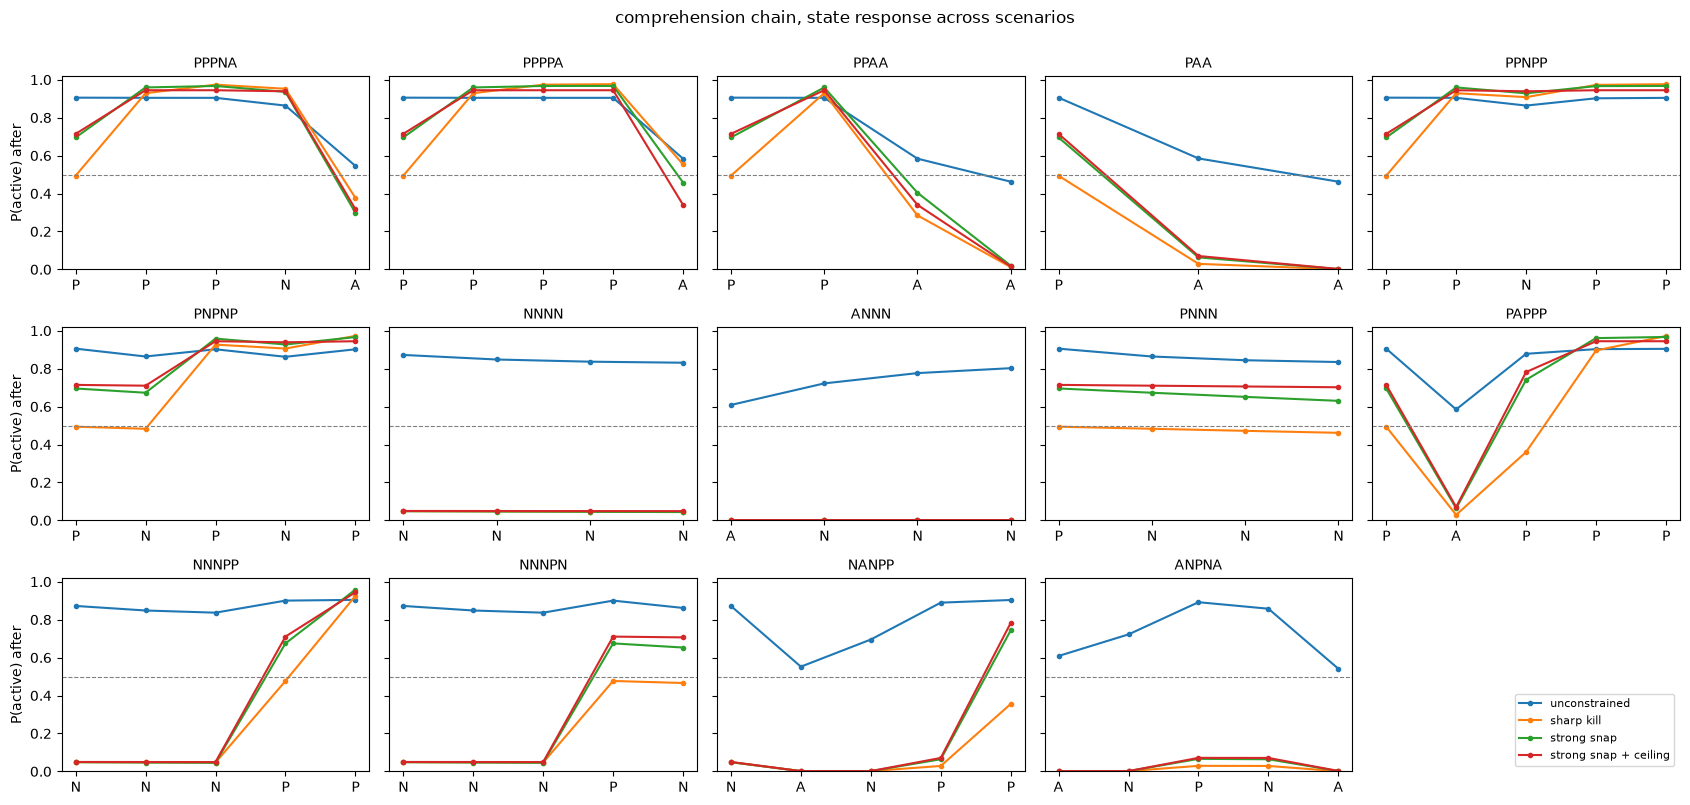

In [5]:
import numpy as np
import matplotlib.pyplot as plt

FAMILY = "comprehension"
VALUE = "state"  # "state" for the disposition, "evidence" for implied P(next cell is P)
SHOW_SCENARIOS = ["unconstrained", "sharp kill", "strong snap", "strong snap + ceiling"]
SCENARIOS = ["PPPNA", "PPPPA", "PPAA", "PAA", "PPNPP", "PNPNP", "NNNN",
             "ANNN", "PNNN", "PAPPP", "NNNPP", "NNNPN", "NANPP", "ANPNA"]
CODE = {"N": 0, "A": 1, "P": 2}

fig, axes = plt.subplots(3, 5, figsize=(17, 8), sharey=True)
for ax, scenario in zip(axes.flat, SCENARIOS):
    symbols = np.array([CODE[symbol] for symbol in scenario])
    for name in SHOW_SCENARIOS:
        chain = getattr(models[name], FAMILY)
        state = chain.predict_state(np.append(symbols, 0))[1:]
        if VALUE == "state":
            trajectory = state
        else:
            trajectory = state * chain.pP_a + (1 - state) * chain.pP_i
        ax.plot(
            range(len(scenario)),
            trajectory,
            marker="o",
            markersize=3,
            label=name,
        )
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xticks(range(len(scenario)))
    ax.set_xticklabels(list(scenario))
    ax.set_title(scenario, fontsize=10)
    ax.set_ylim(0, 1.02)

for row in range(3):
    axes[row, 0].set_ylabel(
        "P(active) after" if VALUE == "state" else "P(next cell is P)"
    )
legend_ax = axes.flat[-1]
legend_ax.axis("off")
handles, labels = axes.flat[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc="lower right", fontsize=8)
fig.suptitle(
    f"{FAMILY} chain, {VALUE} response across scenarios",
    y=1.0,
)
plt.tight_layout()
plt.show()

## 7. Trajectories

The same dialogue under chosen configurations, P(active) before each unit, conditioned on strictly earlier units only. Unit 0 is the solution row. Edit SHOW and DIALOGUE.

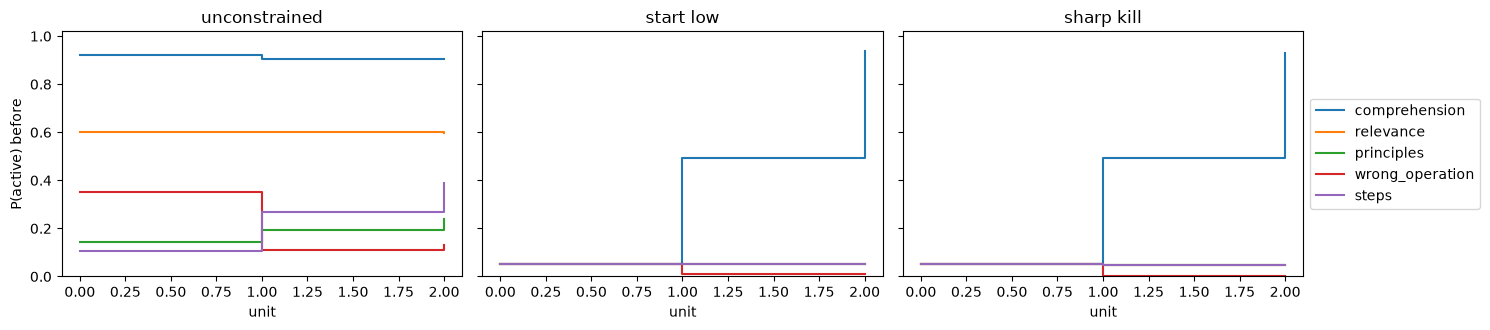

In [6]:
import matplotlib.pyplot as plt

SHOW = ["unconstrained", "start low", "sharp kill"]
DIALOGUE = next(iter(models["sharp kill"].predict_states()))

fig, axes = plt.subplots(1, len(SHOW), figsize=(5 * len(SHOW), 3.4), sharey=True)
for ax, name in zip(axes, SHOW):
    track = models[name].predict_states()[DIALOGUE]
    for j, family in enumerate(FAMILIES):
        ax.step(range(len(track)), track[:, j], where="post", label=family)
    ax.set_title(name)
    ax.set_xlabel("unit")
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel("P(active) before")
axes[-1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## 8. Notes

- Every pin every row is visible in section 3, nothing lives in class defaults, `TriggerChain()` with no arguments pins nothing.
- The sharp-kill family's fitted resolve is the data-estimated kill rate per family, compare it across the kill and snap brackets, stability there is evidence the estimate is real rather than a dial artifact.
- Rows with NaN had no informative test cells of one class for that family.
- The pick made here becomes the chain of record, log the configuration name and its full pin set with the decision.